In [1]:
import axelrod as axl
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


Fuzzy
Fuzzy


KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

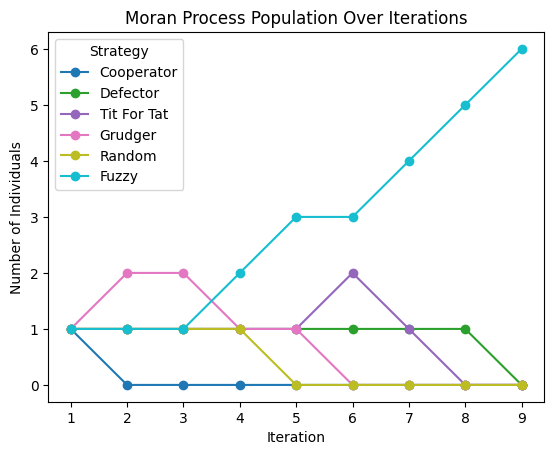

<Figure size 800x500 with 0 Axes>

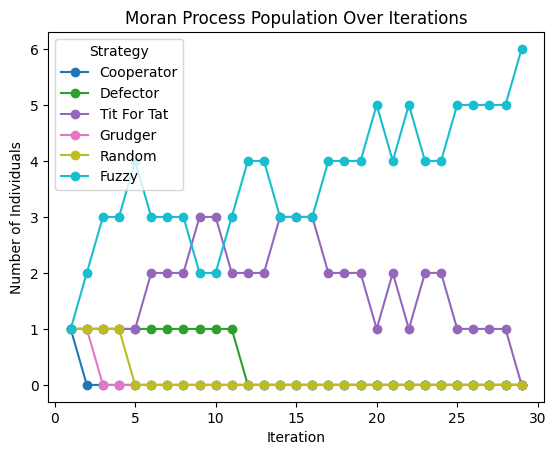

In [19]:
p = [player() for player in axl.demo_strategies] + [axl.Fuzzy()]

for i in range(0, 6):
    mp = axl.MoranProcess(players=p, seed=i)
    populations = mp.play()
    
    data = [[] for player in p]
    pop = mp.populations
    for i in range (0, len(p)):
        for j in range(0, len(pop)):
            if(p[i].name != 'Random'):
                data[i].append(pop[j][p[i].name])
            else:
                data[i].append(pop[j]['Random: 0.5'])

    df = pd.DataFrame(columns=[i for i in range(1, len(mp.populations)+1)], data=data, index=[player.name for player in p])

    plt.figure(figsize=(8, 5))
    df.T.plot(marker="o", linestyle="-", colormap="tab10")

    # Labels and title
    plt.xlabel("Iteration")
    plt.ylabel("Number of Individuals")
    plt.title("Moran Process Population Over Iterations")

    # Show legend
    plt.legend(title="Strategy")
    
    # ax = mp.populations_plot()

    plt.plot()
    print(mp.winning_strategy_name)


In [10]:
#odradi ovo, ali sa 5 najboljih i još par poznatih, pustiti 50 puta. Iskodirati ako je moguće, u kojoj iteraciji od ukupnog broja
#iteracije je Fuzzy preživeo
# p = [player() for player in axl.demo_strategies] + [axl.Fuzzy()]
p = [player for player in[
    axl.Fuzzy(),
    axl.EvolvedFSM6(),
    axl.EvolvedLookerUp2_2_2(),
    axl.EvolvedHMM5(),
    axl.EvolvedFSM16(),
    axl.TitForTat(),
    axl.GTFT(),
    axl.ZDGTFT2()
    ]]
winners = []
dfs = []

for i in range(0, 30):
    mp = axl.MoranProcess(players=p, noise=0.1, stop_on_fixation=True)
    populations = mp.play()
    
    data = [[] for player in p]
    pop = mp.populations
    for i in range (0, len(p)):
        for j in range(0, len(pop)):
            if(p[i].name != 'Random'):
                data[i].append(pop[j][p[i].name])
            else:
                data[i].append(pop[j]['Random: 0.5'])

    df = pd.DataFrame(columns=[i for i in range(1, len(mp.populations)+1)], data=data, index=[player.name for player in p])
    dfs.append(df)

    winners.append(mp.winning_strategy_name)


KeyboardInterrupt: 

In [ ]:
unique_winners = set(winners)

for uw in unique_winners:
    print(uw, winners.count(uw)/len(winners)*100)

Evolved FSM 16 42.857142857142854
Fuzzy 14.285714285714285
Tit For Tat 42.857142857142854


In [50]:
import numpy as np

survival = []
for df in dfs:
    last_pos_col = (
    df.gt(0)                      # step 1
    .iloc[:, ::-1]              # step 2 – reverse the columns
    .apply(                     # step 3
        lambda r: r.idxmax()/df.columns[-1] if r.any() else 0,
        axis=1
        )
    )
    survival.append(last_pos_col)

print(survival)


df = pd.concat(survival, axis=1)

# Optionally rename the columns
df.columns = [f"Moran {i+1}" for i in range(len(survival))]

# Export to Excel
df.to_excel("output.xlsx")



[Fuzzy                   0.965517
EvolvedLookerUp2_2_2    0.068966
Evolved HMM 5           0.206897
Evolved FSM 16          0.137931
Tit For Tat             1.000000
GTFT                    0.000000
ZD-GTFT-2               0.000000
dtype: float64, Fuzzy                   0.961538
EvolvedLookerUp2_2_2    0.153846
Evolved HMM 5           0.115385
Evolved FSM 16          1.000000
Tit For Tat             0.538462
GTFT                    0.000000
ZD-GTFT-2               0.000000
dtype: float64, Fuzzy                   0.090909
EvolvedLookerUp2_2_2    0.909091
Evolved HMM 5           0.272727
Evolved FSM 16          1.000000
Tit For Tat             0.454545
GTFT                    0.000000
ZD-GTFT-2               0.000000
dtype: float64, Fuzzy                   1.000000
EvolvedLookerUp2_2_2    0.133333
Evolved HMM 5           0.200000
Evolved FSM 16          0.066667
Tit For Tat             0.500000
GTFT                    0.000000
ZD-GTFT-2               0.000000
dtype: float64, Fuzzy      

<Figure size 1600x1000 with 0 Axes>

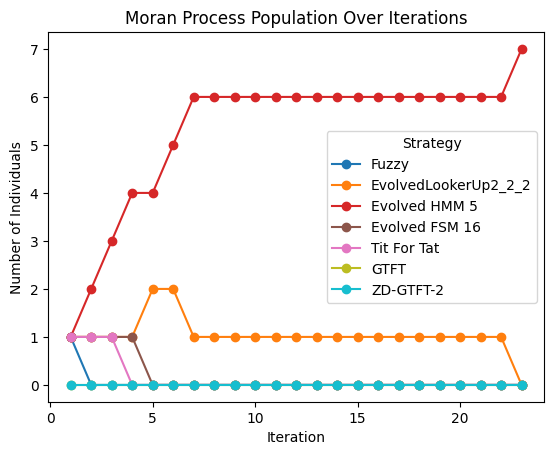

<Figure size 1600x1000 with 0 Axes>

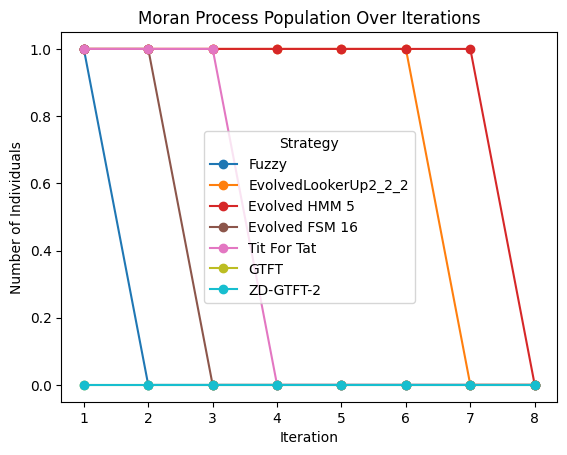

In [ ]:
for df in dfs:
    plt.figure(figsize=(16, 10))
    df.T.plot(marker="o", linestyle="-", colormap="tab10")

    # Labels and title
    plt.xlabel("Iteration")
    plt.ylabel("Number of Individuals")
    plt.title("Moran Process Population Over Iterations")

    # Show legend
    plt.legend(title="Strategy")
    
    # ax = mp.populations_plot()

    plt.plot()

In [8]:
p = [axl.Defector(), axl.Defector(), axl.Fuzzy()]

<Figure size 800x500 with 0 Axes>

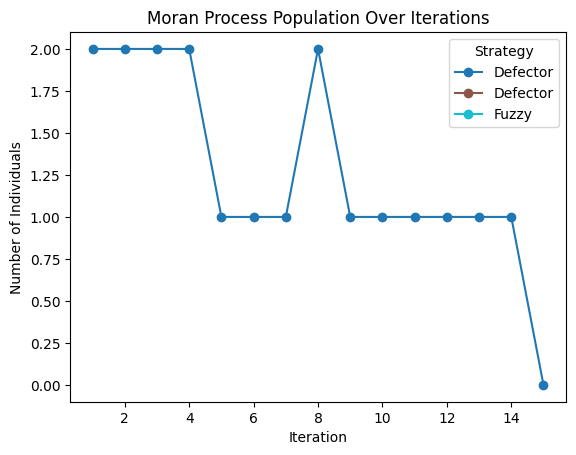

<Figure size 800x500 with 0 Axes>

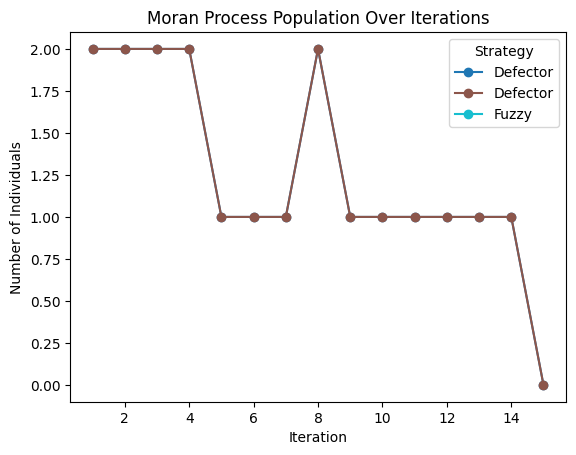

<Figure size 800x500 with 0 Axes>

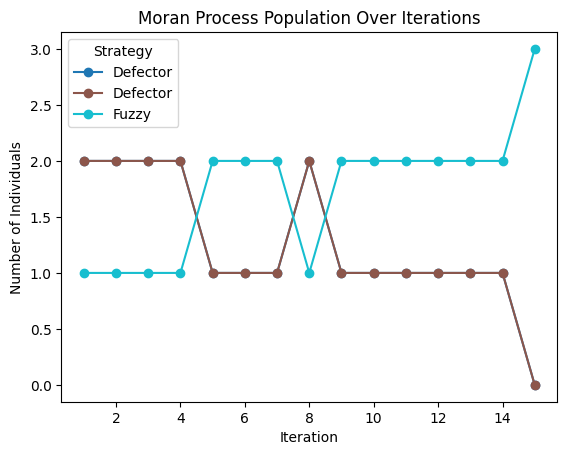

In [9]:
mp = axl.MoranProcess(players=p)
populations = mp.play()
  
data = [[] for player in p]
pop = mp.populations
for i in range (0, len(p)):
    for j in range(0, len(pop)):
        if(p[i].name != 'Random'):
            data[i].append(pop[j][p[i].name])
        else:
            data[i].append(pop[j]['Random: 0.5'])

    df = pd.DataFrame(columns=[i for i in range(1, len(mp.populations)+1)], data=data, index=[player.name for player in p])

    plt.figure(figsize=(8, 5))
    df.T.plot(marker="o", linestyle="-", colormap="tab10")

    # Labels and title
    plt.xlabel("Iteration")
    plt.ylabel("Number of Individuals")
    plt.title("Moran Process Population Over Iterations")

    # Show legend
    plt.legend(title="Strategy")
    
    # ax = mp.populations_plot()

    plt.plot()